In [1]:
!pip install medmnist -q 

import numpy as np
from medmnist import PathMNIST

np.random.seed(42)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 3.3 MB/s eta 0:00:00


In [2]:
train_set = PathMNIST(split="train", size= 28, download=True)
val_set = PathMNIST(split="val", size=28, download=True)
test_set = PathMNIST(split="test", size=28, download=True)

100%|██████████| 206M/206M [00:14<00:00, 14.5MB/s] 


In [3]:
print(type(train_set.imgs), train_set.imgs.shape)
print(type(train_set.labels), train_set.labels.shape)

<class 'numpy.ndarray'> (89996, 28, 28, 3)
<class 'numpy.ndarray'> (89996, 1)


In [4]:
#Função para preparar cada split
def preparar_dados(dataset):
    #1) Pega as imagens e os rótulos brutos
    x = dataset.imgs   # shape (N, 28, 28, 3)
    y= dataset.labels  # shape (N, 1)

    #2) Achatando as imagens: de (N, 28, 28, 3) PARA (N, 2352)
    x = x.reshape(x.shape[0], -1)


    #3) NORMALIZAR os pixels de [0,255] para [0,1] 
    x = x.astype(np.float32) / 255.0


    y = y.flatten()


    return x, y

    #APLICANDO NSO TRÊS SPLITS
x_train, y_train = preparar_dados(train_set)
x_val, y_val = preparar_dados(val_set)
x_test, y_test = preparar_dados(test_set)



#conferindo os shapes resultantes
print("X_train:", x_train.shape, "| y_train:", y_train.shape)
print("x_val: ", x_val.shape, "| y_val: ", y_val.shape)
print("Valor min/max dos pixels:", x_train.min(), x_train.max())  # esperado: 0.0 e 1.0
print("Classes presentes:", np.unique(y_train))  # esperado: [0 1 2 3 4 5 6 7 8]

X_train: (89996, 2352) | y_train: (89996,)
x_val:  (10004, 2352) | y_val:  (10004,)
Valor min/max dos pixels: 0.0 1.0
Classes presentes: [0 1 2 3 4 5 6 7 8]


In [5]:
# ============================================================
# BLOCO 1 — Funções de ativação e suas derivadas
# ============================================================

# ----- ReLU -----
# f(z) = max(0, z)  -> zera valores negativos, mantém positivos
def relu(z):
    return np.maximum(0, z)

# Derivada da ReLU: 1 onde z > 0, e 0 onde z <= 0
def relu_derivada(z):
    return (z > 0).astype(np.float32)


# ----- Sigmoid -----
# f(z) = 1 / (1 + e^-z)  -> "achata" qualquer número pra faixa (0, 1)
def sigmoid(z):
    z = np.clip(z, -500, 500)  # evita overflow no exp()
    return 1.0 / (1.0 + np.exp(-z))

# Derivada da Sigmoid: f(z) * (1 - f(z))
def sigmoid_derivada(z):
    s = sigmoid(z)
    return s * (1.0 - s)


# ----- Teste rápido das funções -----
teste = np.array([-2.0, -0.5, 0.0, 0.5, 2.0], dtype=np.float32)
print("Entrada:         ", teste)
print("ReLU:            ", relu(teste))
print("ReLU derivada:   ", relu_derivada(teste))
print("Sigmoid:         ", np.round(sigmoid(teste), 4))
print("Sigmoid derivada:", np.round(sigmoid_derivada(teste), 4))

Entrada:          [-2.  -0.5  0.   0.5  2. ]
ReLU:             [0.  0.  0.  0.5 2. ]
ReLU derivada:    [0. 0. 0. 1. 1.]
Sigmoid:          [0.1192 0.3775 0.5    0.6225 0.8808]
Sigmoid derivada: [0.105 0.235 0.25  0.235 0.105]


In [6]:
# ============================================================
# BLOCO 2 — Softmax + Cross-Entropy (numericamente estáveis)
# ============================================================

def softmax(logits):
    """
    logits: array (N, 9) com os valores brutos da última camada.
    Retorna (N, 9) com probabilidades que somam 1 em cada linha.
    """
    # Deslocamento pelo máximo (estabilidade numérica - exigência do enunciado)
    # Subtrai o maior valor de cada linha antes do exp, evitando overflow.
    z_shift = logits - np.max(logits, axis=1, keepdims=True)
    exp = np.exp(z_shift)
    return exp / np.sum(exp, axis=1, keepdims=True)


def cross_entropy(y_pred, y_true_onehot):
    """
    y_pred:        (N, 9) probabilidades vindas do softmax.
    y_true_onehot: (N, 9) rótulos em one-hot.
    Retorna a perda média (escalar) sobre as N amostras.
    """
    N = y_pred.shape[0]
    eps = 1e-12  # evita log(0) = -infinito
    # Soma apenas a probabilidade da classe correta (graças ao one-hot)
    log_likelihood = -np.sum(y_true_onehot * np.log(y_pred + eps), axis=1)
    return np.mean(log_likelihood)


# ----- Função auxiliar: converter rótulos inteiros em one-hot -----
def to_onehot(y, num_classes=9):
    """
    y: vetor (N,) de inteiros 0..8.
    Retorna (N, 9) com 1 na coluna da classe certa.
    """
    onehot = np.zeros((y.shape[0], num_classes), dtype=np.float32)
    onehot[np.arange(y.shape[0]), y] = 1.0
    return onehot


# ----- Teste rápido -----
logits_teste = np.array([[2.0, 1.0, 0.1],
                         [0.5, 2.5, 0.3]], dtype=np.float32)
probs = softmax(logits_teste)
print("Probabilidades:\n", np.round(probs, 4))
print("Soma de cada linha (deve dar 1):", np.round(probs.sum(axis=1), 6))

# Teste da cross-entropy e do one-hot
y_int = np.array([0, 1])               # classes corretas
y_oh  = to_onehot(y_int, num_classes=3)
print("One-hot:\n", y_oh)
print("Perda (cross-entropy):", round(cross_entropy(probs, y_oh), 4))

Probabilidades:
 [[0.659  0.2424 0.0986]
 [0.1086 0.8025 0.0889]]
Soma de cada linha (deve dar 1): [1. 1.]
One-hot:
 [[1. 0. 0.]
 [0. 1. 0.]]
Perda (cross-entropy): 0.3185


In [7]:
# ============================================================
# BLOCO 3 — A classe da MLP e inicialização dos pesos (He)
# ============================================================

class MLP:
    def __init__(self, tamanhos, seed=42):
        """
        tamanhos: lista com o nº de neurônios por camada.
                  Ex.: [2352, 128, 64, 9]
                  -> entrada 2352, ocultas 128 e 64, saída 9 classes.
        """
        np.random.seed(seed)
        self.tamanhos = tamanhos
        self.num_camadas = len(tamanhos) - 1  # nº de conjuntos (W, b)

        self.pesos = []   # lista de matrizes W
        self.biases = []  # lista de vetores b

        # Cria (W, b) entre cada par de camadas consecutivas
        for i in range(self.num_camadas):
            n_entrada = tamanhos[i]
            n_saida   = tamanhos[i + 1]

            # Inicialização He: normal * sqrt(2 / n_entrada)
            W = np.random.randn(n_entrada, n_saida).astype(np.float32) * np.sqrt(2.0 / n_entrada)
            b = np.zeros((1, n_saida), dtype=np.float32)

            self.pesos.append(W)
            self.biases.append(b)

    def resumo(self):
        """Imprime o formato de cada camada (útil pra conferir e pra defesa)."""
        print(f"Arquitetura: {self.tamanhos}")
        print(f"Número de camadas com parâmetros: {self.num_camadas}\n")
        total = 0
        for i in range(self.num_camadas):
            W, b = self.pesos[i], self.biases[i]
            params = W.size + b.size
            total += params
            print(f"Camada {i+1}: W{W.shape}  b{b.shape}  -> {params:,} parâmetros")
        print(f"\nTotal de parâmetros treináveis: {total:,}")


# ----- Teste: criar a rede e ver o resumo -----
rede = MLP([2352, 128, 64, 9], seed=42)
rede.resumo()

# Conferir que a inicialização He produziu valores numa faixa saudável
print("\nMédia dos pesos da 1ª camada:", round(rede.pesos[0].mean(), 5), "(esperado ~0)")
print("Desvio-padrão da 1ª camada:  ", round(rede.pesos[0].std(), 5),
      "(esperado ~", round(np.sqrt(2/2352), 5), ")")

Arquitetura: [2352, 128, 64, 9]
Número de camadas com parâmetros: 3

Camada 1: W(2352, 128)  b(1, 128)  -> 301,184 parâmetros
Camada 2: W(128, 64)  b(1, 64)  -> 8,256 parâmetros
Camada 3: W(64, 9)  b(1, 9)  -> 585 parâmetros

Total de parâmetros treináveis: 310,025

Média dos pesos da 1ª camada: 0.0 (esperado ~0)
Desvio-padrão da 1ª camada:   0.02915 (esperado ~ 0.02916 )


In [8]:
# ============================================================
# BLOCO 4 — Forward Propagation
# ============================================================

def forward(rede, X):
    """
    rede: instância de MLP.
    X:    (batch, 2352) — entrada já achatada e normalizada.

    Retorna:
      saida: (batch, 9) probabilidades do softmax.
      cache: dicionário com os intermediários (z e a de cada camada),
             necessários para a backpropagation.
    """
    cache = {"a": [X], "z": []}  # a[0] é a própria entrada
    a = X

    for i in range(rede.num_camadas):
        # 1) Parte linear: z = a @ W + b
        z = a @ rede.pesos[i] + rede.biases[i]
        cache["z"].append(z)

        # 2) Parte não-linear
        if i < rede.num_camadas - 1:
            # Camadas ocultas: ReLU
            a = relu(z)
        else:
            # Última camada: Softmax (vira probabilidades)
            a = softmax(z)

        cache["a"].append(a)

    saida = a
    return saida, cache


# ----- Teste: passar um batch pequeno pela rede -----
X_batch = x_train[:5]            # 5 imagens
saida, cache = forward(rede, X_batch)

print("Shape da saída:", saida.shape, "(esperado (5, 9))")
print("\nProbabilidades da 1ª imagem:\n", np.round(saida[0], 4))
print("Soma das probabilidades (deve dar 1):", round(saida[0].sum(), 6))
print("Classe prevista p/ cada imagem:", np.argmax(saida, axis=1))
print("Classe verdadeira de cada uma: ", y_train[:5])

Shape da saída: (5, 9) (esperado (5, 9))

Probabilidades da 1ª imagem:
 [0.0348 0.1081 0.0461 0.0031 0.3248 0.2465 0.0541 0.1436 0.0388]
Soma das probabilidades (deve dar 1): 1.0
Classe prevista p/ cada imagem: [4 4 4 4 4]
Classe verdadeira de cada uma:  [0 4 7 5 5]


In [9]:
# ============================================================
# BLOCO 5 — Backward Propagation
# ============================================================

def backward(rede, cache, y_onehot):
    """
    rede:     instância de MLP (com os pesos atuais).
    cache:    dicionário retornado pelo forward (com 'a' e 'z').
    y_onehot: (batch, 9) rótulos verdadeiros em one-hot.

    Retorna:
      grads_W: lista com o gradiente de cada matriz de pesos.
      grads_b: lista com o gradiente de cada bias.
    """
    batch = y_onehot.shape[0]
    grads_W = [None] * rede.num_camadas
    grads_b = [None] * rede.num_camadas

    # --- Gradiente na saída (o "presente" Softmax + Cross-Entropy) ---
    # dL/dz da última camada = (previsão - verdadeiro) / batch
    a_saida = cache["a"][-1]            # previsão do softmax
    dz = (a_saida - y_onehot) / batch  # divide por batch p/ média

    # --- Propaga de trás pra frente ---
    for i in reversed(range(rede.num_camadas)):
        a_anterior = cache["a"][i]      # ativação que ENTROU nesta camada

        # Gradiente dos pesos e do bias desta camada
        grads_W[i] = a_anterior.T @ dz                 # (n_entrada, n_saida)
        grads_b[i] = np.sum(dz, axis=0, keepdims=True) # (1, n_saida)

        # Propaga o gradiente para a camada anterior (se não for a 1ª)
        if i > 0:
            z_anterior = cache["z"][i - 1]
            # Passa pelo peso (transposto) e depois pela derivada da ReLU
            da_anterior = dz @ rede.pesos[i].T
            dz = da_anterior * relu_derivada(z_anterior)

    return grads_W, grads_b


# ----- Teste: rodar um forward + backward e conferir os shapes -----
X_batch = x_train[:5]
y_batch = to_onehot(y_train[:5], num_classes=9)

saida, cache = forward(rede, X_batch)
grads_W, grads_b = backward(rede, cache, y_batch)

print("Conferindo se cada gradiente tem o MESMO shape do parâmetro:\n")
for i in range(rede.num_camadas):
    okW = grads_W[i].shape == rede.pesos[i].shape
    okb = grads_b[i].shape == rede.biases[i].shape
    print(f"Camada {i+1}: grad_W {grads_W[i].shape} == W {rede.pesos[i].shape}? {okW} | "
          f"grad_b {grads_b[i].shape} == b {rede.biases[i].shape}? {okb}")

Conferindo se cada gradiente tem o MESMO shape do parâmetro:

Camada 1: grad_W (2352, 128) == W (2352, 128)? True | grad_b (1, 128) == b (1, 128)? True
Camada 2: grad_W (128, 64) == W (128, 64)? True | grad_b (1, 64) == b (1, 64)? True
Camada 3: grad_W (64, 9) == W (64, 9)? True | grad_b (1, 9) == b (1, 9)? True


In [10]:
# ============================================================
# BLOCO 6 — SGD com Momentum
# ============================================================

class SGDMomentum:
    def __init__(self, rede, learning_rate=0.01, beta=0.9):
        """
        rede:          instância de MLP cujos pesos serão atualizados.
        learning_rate: η (eta) — tamanho do passo.
        beta:          β — fração da velocidade anterior mantida (memória).
        """
        self.rede = rede
        self.lr = learning_rate
        self.beta = beta

        # Velocidade inicial = zero, com o mesmo shape de cada parâmetro
        self.vW = [np.zeros_like(W) for W in rede.pesos]
        self.vb = [np.zeros_like(b) for b in rede.biases]

    def step(self, grads_W, grads_b):
        """Aplica uma atualização dos pesos usando os gradientes do backward."""
        for i in range(self.rede.num_camadas):
            # v <- beta*v + lr*grad   (acúmulo de velocidade)
            self.vW[i] = self.beta * self.vW[i] + self.lr * grads_W[i]
            self.vb[i] = self.beta * self.vb[i] + self.lr * grads_b[i]

            # W <- W - v   (passo na direção da velocidade)
            self.rede.pesos[i]  -= self.vW[i]
            self.rede.biases[i] -= self.vb[i]


# ----- Teste: provar que um passo REDUZ a perda -----
X_batch = x_train[:64]
y_int   = y_train[:64]
y_batch = to_onehot(y_int, num_classes=9)

# Rede e otimizador novos (pra teste limpo)
rede_teste = MLP([2352, 128, 64, 9], seed=42)
otim = SGDMomentum(rede_teste, learning_rate=0.01, beta=0.9)

print("Perda ao longo de 10 passos no mesmo batch (deve cair):")
for passo in range(10):
    saida, cache = forward(rede_teste, X_batch)
    perda = cross_entropy(saida, y_batch)
    grads_W, grads_b = backward(rede_teste, cache, y_batch)
    otim.step(grads_W, grads_b)
    print(f"  Passo {passo+1:2d}: perda = {perda:.4f}")

Perda ao longo de 10 passos no mesmo batch (deve cair):
  Passo  1: perda = 2.6020
  Passo  2: perda = 2.3077
  Passo  3: perda = 2.2525
  Passo  4: perda = 2.1937
  Passo  5: perda = 2.1627
  Passo  6: perda = 2.1534
  Passo  7: perda = 2.1502
  Passo  8: perda = 2.1353
  Passo  9: perda = 2.1142
  Passo 10: perda = 2.0998


In [11]:
# ============================================================
# BLOCO 7 — Gradient Checking (validação numérica obrigatória)
# ============================================================

def gradient_check(rede, X, y_onehot, camada=0, n_amostras=5, epsilon=1e-5):
    """
    Compara o gradiente ANALÍTICO (backward) com o NUMÉRICO
    em alguns pesos de uma camada.

    camada:     índice da camada cujos pesos serão checados.
    n_amostras: quantos pesos aleatórios dessa camada testar.
    epsilon:    o ε da aproximação por diferença central.
    """
    # 1) Gradiente analítico (nossa backprop)
    saida, cache = forward(rede, X)
    grads_W, grads_b = backward(rede, cache, y_onehot)
    grad_analitico = grads_W[camada]

    W = rede.pesos[camada]
    diffs = []

    print(f"Checando {n_amostras} pesos aleatórios da camada {camada+1}:\n")
    print(f"{'analítico':>14} {'numérico':>14} {'dif. relativa':>16}")

    for _ in range(n_amostras):
        # Escolhe uma posição (i, j) aleatória dentro da matriz W
        i = np.random.randint(W.shape[0])
        j = np.random.randint(W.shape[1])

        valor_original = W[i, j]

        # perda(W + epsilon)
        W[i, j] = valor_original + epsilon
        saida_mais, _ = forward(rede, X)
        perda_mais = cross_entropy(saida_mais, y_onehot)

        # perda(W - epsilon)
        W[i, j] = valor_original - epsilon
        saida_menos, _ = forward(rede, X)
        perda_menos = cross_entropy(saida_menos, y_onehot)

        # Restaura o peso original (MUITO importante)
        W[i, j] = valor_original

        # Diferença central
        grad_num = (perda_mais - perda_menos) / (2 * epsilon)
        grad_ana = grad_analitico[i, j]

        # Diferença relativa entre os dois
        denom = max(abs(grad_ana) + abs(grad_num), 1e-12)
        dif_rel = abs(grad_ana - grad_num) / denom
        diffs.append(dif_rel)

        print(f"{grad_ana:14.8f} {grad_num:14.8f} {dif_rel:16.2e}")

    pior = max(diffs)
    print(f"\nPior diferença relativa: {pior:.2e}")
    print("Resultado:", "PASSOU ✓ (< 1e-5)" if pior < 1e-5 else "FALHOU ✗ (>= 1e-5)")


# ----- Rodar o gradient checking -----
# Batch pequeno, de propósito: o teste é de corretude, não de performance.
np.random.seed(0)
X_check = x_train[:10]
y_check = to_onehot(y_train[:10], num_classes=9)

rede_check = MLP([2352, 128, 64, 9], seed=42)

# Checa a 1ª camada e a última
gradient_check(rede_check, X_check, y_check, camada=0, n_amostras=5)
print("\n" + "="*50 + "\n")
gradient_check(rede_check, X_check, y_check, camada=2, n_amostras=5)

Checando 5 pesos aleatórios da camada 1:

     analítico       numérico    dif. relativa
    0.00639389     0.00639389         1.01e-09
    0.00033373     0.00033373         6.64e-09
   -0.01450721    -0.01450721         1.00e-09
    0.00000000     0.00000000         0.00e+00
    0.00000000     0.00000000         0.00e+00

Pior diferença relativa: 6.64e-09
Resultado: PASSOU ✓ (< 1e-5)


Checando 5 pesos aleatórios da camada 3:

     analítico       numérico    dif. relativa
    0.24865964     0.24865964         5.74e-11
    0.00189963     0.00189963         4.07e-09
    0.00000000     0.00000000         0.00e+00
    0.00000000     0.00000000         0.00e+00
   -0.06402299    -0.06402299         1.41e-10

Pior diferença relativa: 4.07e-09
Resultado: PASSOU ✓ (< 1e-5)


In [12]:
# ============================================================
# BLOCO 8 — Loop de Treino
# ============================================================

# ---- Botões de controle de tempo ----
EPOCAS      = 20        # passadas completas pelo dataset de treino
BATCH_SIZE  = 128       # imagens por mini-batch
LR          = 0.005      # learning rate
BETA        = 0.9       # momentum
TAM_SUBSET  = 20000     # use None p/ treinar com TODAS as ~90k imagens.
                        # 20000 deixa rápido sem perder a didática.

# ---- Função auxiliar: acurácia ----
def acuracia(rede, X, y_int, batch=512):
    """Calcula acurácia em lotes (pra não estourar memória)."""
    acertos = 0
    for ini in range(0, X.shape[0], batch):
        Xb = X[ini:ini+batch]
        saida, _ = forward(rede, Xb)
        preds = np.argmax(saida, axis=1)
        acertos += np.sum(preds == y_int[ini:ini+batch])
    return acertos / X.shape[0]

# ---- Preparar dados de treino ----
if TAM_SUBSET is not None:
    Xtr, ytr = x_train[:TAM_SUBSET], y_train[:TAM_SUBSET]
else:
    Xtr, ytr = x_train, y_train
ytr_oh = to_onehot(ytr, num_classes=9)

# ---- Rede e otimizador ----
rede_final = MLP([2352, 256, 128, 9], seed=42)
otim = SGDMomentum(rede_final, learning_rate=LR, beta=BETA)

# ---- Histórico (pra plotar depois) ----
hist = {"loss": [], "acc_tr": [], "acc_val": []}

n = Xtr.shape[0]
print(f"Treinando com {n} imagens, {EPOCAS} épocas, batch {BATCH_SIZE}...\n")

for ep in range(EPOCAS):
    # Embaralha a ordem das imagens a cada época (importante!)
    ordem = np.random.permutation(n)
    Xs, ys_oh = Xtr[ordem], ytr_oh[ordem]

    perda_acum = 0.0
    n_batches = 0

    for ini in range(0, n, BATCH_SIZE):
        Xb = Xs[ini:ini+BATCH_SIZE]
        yb = ys_oh[ini:ini+BATCH_SIZE]

        saida, cache = forward(rede_final, Xb)
        perda_acum += cross_entropy(saida, yb)
        n_batches += 1

        grads_W, grads_b = backward(rede_final, cache, yb)
        otim.step(grads_W, grads_b)

    # Métricas da época
    loss_ep = perda_acum / n_batches
    acc_tr  = acuracia(rede_final, Xtr, ytr)
    acc_val = acuracia(rede_final, x_val, y_val)

    hist["loss"].append(loss_ep)
    hist["acc_tr"].append(acc_tr)
    hist["acc_val"].append(acc_val)

    print(f"Época {ep+1:2d}/{EPOCAS} | perda {loss_ep:.4f} | "
          f"acc treino {acc_tr:.4f} | acc val {acc_val:.4f}")

print("\nTreino concluído.")

Treinando com 20000 imagens, 20 épocas, batch 128...

Época  1/20 | perda 1.9908 | acc treino 0.2493 | acc val 0.2463
Época  2/20 | perda 1.7696 | acc treino 0.3776 | acc val 0.3668
Época  3/20 | perda 1.6490 | acc treino 0.4169 | acc val 0.4155
Época  4/20 | perda 1.6074 | acc treino 0.4119 | acc val 0.4055
Época  5/20 | perda 1.5667 | acc treino 0.4060 | acc val 0.4011
Época  6/20 | perda 1.5318 | acc treino 0.4373 | acc val 0.4307
Época  7/20 | perda 1.5044 | acc treino 0.4722 | acc val 0.4634
Época  8/20 | perda 1.4675 | acc treino 0.4592 | acc val 0.4502
Época  9/20 | perda 1.4447 | acc treino 0.4883 | acc val 0.4803
Época 10/20 | perda 1.4332 | acc treino 0.4341 | acc val 0.4254
Época 11/20 | perda 1.4023 | acc treino 0.4524 | acc val 0.4353
Época 12/20 | perda 1.3787 | acc treino 0.4410 | acc val 0.4319
Época 13/20 | perda 1.3866 | acc treino 0.4928 | acc val 0.4807
Época 14/20 | perda 1.3944 | acc treino 0.4904 | acc val 0.4817
Época 15/20 | perda 1.3678 | acc treino 0.4975 | a

Figura salva como 'curvas_treino_numpy.png'


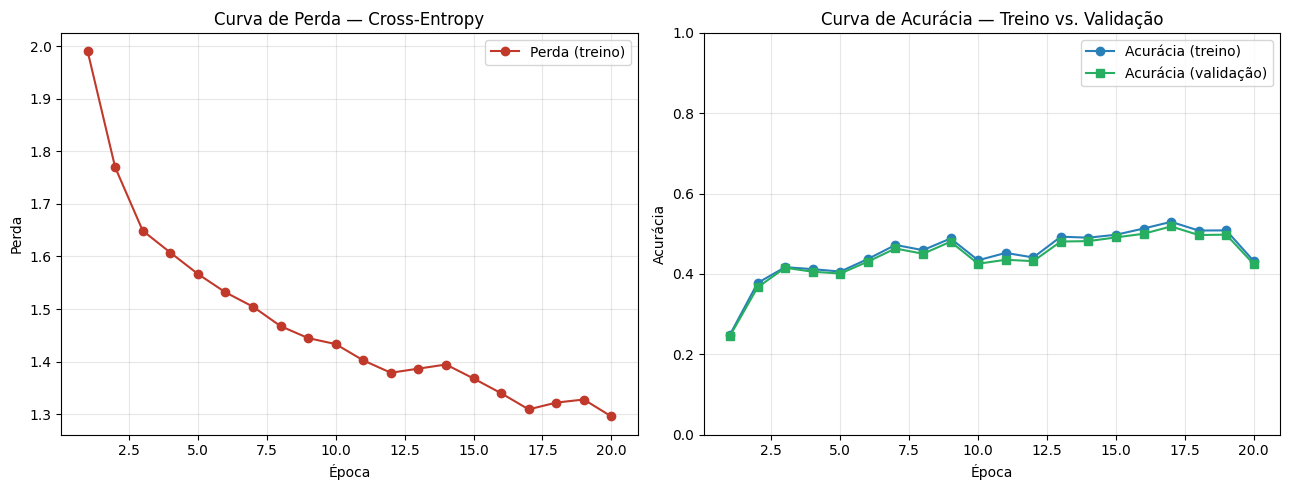

In [13]:
# ============================================================
# BLOCO 9 — Visualização das curvas de treino
# ============================================================
import matplotlib.pyplot as plt

epocas = range(1, len(hist["loss"]) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# ----- Gráfico 1: Perda -----
ax1.plot(epocas, hist["loss"], marker="o", color="#c0392b", label="Perda (treino)")
ax1.set_title("Curva de Perda — Cross-Entropy")
ax1.set_xlabel("Época")
ax1.set_ylabel("Perda")
ax1.grid(True, alpha=0.3)
ax1.legend()

# ----- Gráfico 2: Acurácia (treino vs. validação) -----
ax2.plot(epocas, hist["acc_tr"],  marker="o", color="#2980b9", label="Acurácia (treino)")
ax2.plot(epocas, hist["acc_val"], marker="s", color="#27ae60", label="Acurácia (validação)")
ax2.set_title("Curva de Acurácia — Treino vs. Validação")
ax2.set_xlabel("Época")
ax2.set_ylabel("Acurácia")
ax2.set_ylim(0, 1)
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()

# Salvar a figura para o relatório (pasta figures/)
plt.savefig("curvas_treino_numpy.png", dpi=150, bbox_inches="tight")
print("Figura salva como 'curvas_treino_numpy.png'")

plt.show()